After constructing the final phase 01 dataset, adding circuit features, i will try to predict the Japan 2026 GP Results, to test the model/dataset

In [13]:
import fastf1
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from xgboost import XGBClassifier, XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import spearmanr
import shap
import matplotlib.pyplot as plt

In [14]:
data = pd.read_parquet('/Users/dimkostir/Desktop/Projects/f1-predictions/data/processed/final_phase_01/final_01_circuits.parquet')

In [15]:
data['Year'].value_counts().sort_index()

Year
2022    440
2023    440
2024    479
2025    479
2026     66
Name: count, dtype: int64

In [16]:
print(f"FP2 features shape: {data.shape}")
print(f"Master Phase 2 shape: {data.shape}")
print(f"\nColumns in master2:\n{data.columns.tolist()}")
print(f"\nNull counts:\n{data.isnull().sum()}")

FP2 features shape: (1904, 19)
Master Phase 2 shape: (1904, 19)

Columns in master2:
['Driver', 'TeamName_x', 'GridPosition', 'Finish_Position', 'Status', 'delta_to_pole', 'Qual_Position', 'Year', 'Location', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate', 'circuit_length', 'num_corners', 'num_drs_zones', 'avg_speed_kmh', 'safety_car_rate', 'track_type', 'overtaking_ability']

Null counts:
Driver                  0
TeamName_x              0
GridPosition            2
Finish_Position         2
Status                  0
delta_to_pole          22
Qual_Position           4
Year                    0
Location                0
fp2_median_pace       476
fp2_team_dif          501
fp2_deg_rate          583
circuit_length        440
num_corners           440
num_drs_zones         440
avg_speed_kmh         440
safety_car_rate       440
track_type            440
overtaking_ability    440
dtype: int64


In [17]:
training_data = data.query("Year == 2024 or Year == 2025 or Year == 2022 or Year == 2023 or (Year == 2026 and Location != 'Shanghai')")
training_data.shape

(1882, 19)

In [18]:
training_data['Year'].value_counts().sort_index()

Year
2022    440
2023    440
2024    479
2025    479
2026     44
Name: count, dtype: int64

In [19]:
test_data = data.query("Year == 2026 and Location == 'Shanghai'")
print(test_data.shape)
test_data.head(10)

(22, 19)


,Driver,TeamName_x,GridPosition,Finish_Position,Status,delta_to_pole,Qual_Position,Year,Location,fp2_median_pace,fp2_team_dif,fp2_deg_rate,circuit_length,num_corners,num_drs_zones,avg_speed_kmh,safety_car_rate,track_type,overtaking_ability
1860,ANT,Mercedes,1.0,1.0,Finished,0.000,1.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1861,RUS,Mercedes,2.0,2.0,Finished,0.222,2.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1862,HAM,Ferrari,3.0,3.0,Finished,0.351,3.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1863,LEC,Ferrari,4.0,4.0,Finished,0.364,4.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1864,BEA,Haas F1 Team,10.0,5.0,Finished,1.228,10.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1865,GAS,Alpine,7.0,6.0,Finished,0.809,7.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1866,LAW,Racing Bulls,14.0,7.0,Finished,1.701,14.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1867,HAD,Red Bull Racing,9.0,8.0,Finished,1.057,9.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1868,SAI,Williams,17.0,9.0,Lapped,2.253,17.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58
1869,COL,Alpine,12.0,10.0,Lapped,1.293,12.0,2026,Shanghai,NaN,NaN,NaN,5451.0,16.0,2.0,205.0,0.1,permanent,0.58


In [20]:
print(training_data['Finish_Position'].isnull().sum())
print(test_data['Finish_Position'].isnull().sum())

2
0


In [21]:
le = LabelEncoder()
# Fit on training
training_data["track_type"] = le.fit_transform(training_data["track_type"])

# Transform test
test_data["track_type"] = le.transform(test_data["track_type"])

training_clean = training_data[training_data["Finish_Position"].notna()].copy()

/var/folders/s0/k6p2569n6w1br5pz86sgwm400000gn/T/ipykernel_7791/2063686892.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_data["track_type"] = le.fit_transform(training_data["track_type"])
/var/folders/s0/k6p2569n6w1br5pz86sgwm400000gn/T/ipykernel_7791/2063686892.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["track_type"] = le.transform(test_data["track_type"])


In [22]:
X_train = training_clean.drop(columns = ["Driver", "TeamName_x", "Status", "Year", "Location", "Finish_Position"], axis =1)
y_train = training_clean["Finish_Position"].dropna().astype(int)

X_test = test_data.drop(columns = ["Driver", "TeamName_x", "Status", "Year", "Location", "Finish_Position"], axis = 1)
y_test = test_data["Finish_Position"].astype(int)

bst = XGBRegressor(n_estimators = 200, max_depth = 4, learning_rate = 0.01)
bst.fit(X_train, y_train)

china_2026_predictions = bst.predict(X_test)

In [23]:
print("Training Complete!\n")
print(f"China 2026 Predictions:{china_2026_predictions}")

Training Complete!

China 2026 Predictions:[ 4.0807905  4.604104   6.168198   5.9139585 11.076689   8.774988
 13.269733  10.967188  13.830961  11.466289  11.466289  13.269733
 14.636171  12.752572  14.576117  10.164214  14.636171  14.636171
  7.12628    7.565484  13.830961  14.516236 ]


In [24]:
china_results = pd.DataFrame({
    'Driver': test_data['Driver'].values,
    'Grid Position': test_data['GridPosition'].values,
    'Actual_finish': test_data['Finish_Position'].values,
    'Predicted_score': china_2026_predictions
})

china_results["Actual_finish"] =  china_results["Actual_finish"].astype(int)

china_results['Predicted_finish'] = china_results['Predicted_score'].rank(method = 'dense').astype(int)
china_results.sort_values('Actual_finish')

china_results[['Driver', 'Actual_finish', 'Predicted_finish']]

,Driver,Actual_finish,Predicted_finish
0,ANT,1,1
1,RUS,2,2
2,HAM,3,4
3,LEC,4,3
4,BEA,5,10
5,GAS,6,7
6,LAW,7,13
7,HAD,8,9
8,SAI,9,14
9,COL,10,11


In [25]:
# Spearman between predicted rank and actual finish
spearman_corr, p_value = spearmanr(
    china_results['Predicted_finish'],  # Use raw scores for ranking
    china_results['Actual_finish']
)

print(f"\n{'='*60}")
print(f"SPEARMAN CORRELATION: {spearman_corr:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"{'='*60}")


SPEARMAN CORRELATION: 0.577
P-value: 0.0050


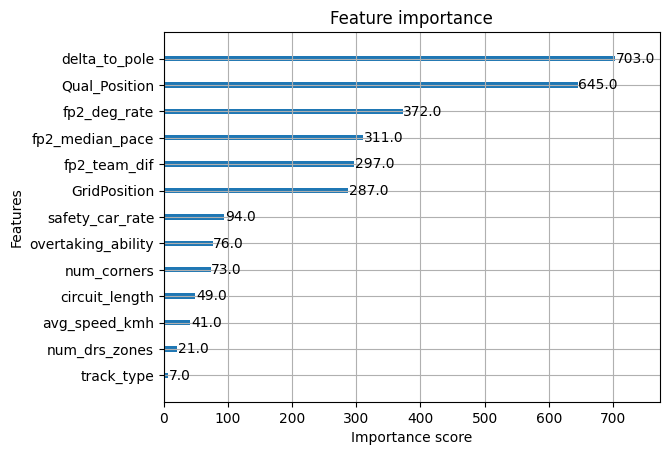

In [26]:
plot_importance(bst)
plt.show()

In [27]:
print("Features in X_train:")
print(X_train.columns.tolist())

# Print ALL columns in training_clean
print("Columns in training_clean:")
print(training_clean.columns.tolist())

# Check if any race-based features leaked
race_features = ['Median_lap_time', 'team_dif', 'Deg_Rate_Weighted', 'dnf']
leaked = [col for col in training_clean.columns if col in race_features]

if leaked:
    print(f"\n⚠️ WARNING: Race features found: {leaked}")
else:
    print("\n✅ No obvious race features in training data")

Features in X_train:
['GridPosition', 'delta_to_pole', 'Qual_Position', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate', 'circuit_length', 'num_corners', 'num_drs_zones', 'avg_speed_kmh', 'safety_car_rate', 'track_type', 'overtaking_ability']
Columns in training_clean:
['Driver', 'TeamName_x', 'GridPosition', 'Finish_Position', 'Status', 'delta_to_pole', 'Qual_Position', 'Year', 'Location', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate', 'circuit_length', 'num_corners', 'num_drs_zones', 'avg_speed_kmh', 'safety_car_rate', 'track_type', 'overtaking_ability']

✅ No obvious race features in training data


In [28]:
# Check X_train columns
print("\nX_train columns:")
print(X_train.columns.tolist())
print(f"X_train shape: {X_train.shape}")

# Expected: 13 columns (after dropping Driver, Team, Status, Year, Location, Finish_Position)
# If more than 13, something leaked

['GridPosition', 'delta_to_pole', 'Qual_Position',
 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate',
 'circuit_length', 'num_corners', 'num_drs_zones',
 'avg_speed_kmh', 'safety_car_rate', 'overtaking_difficulty',
 'track_type']


X_train columns:
['GridPosition', 'delta_to_pole', 'Qual_Position', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate', 'circuit_length', 'num_corners', 'num_drs_zones', 'avg_speed_kmh', 'safety_car_rate', 'track_type', 'overtaking_ability']
X_train shape: (1880, 13)


['GridPosition',
 'delta_to_pole',
 'Qual_Position',
 'fp2_median_pace',
 'fp2_team_dif',
 'fp2_deg_rate',
 'circuit_length',
 'num_corners',
 'num_drs_zones',
 'avg_speed_kmh',
 'safety_car_rate',
 'overtaking_difficulty',
 'track_type']

In [29]:
# 1. Print training columns
print("Training columns:", training_clean.columns.tolist())

# 2. Print X_train columns  
print("\nX_train columns:", X_train.columns.tolist())

# 3. Check for race features
race_features = ['Median_lap_time', 'team_dif', 'Deg_Rate_Weighted']
leaked = [col for col in X_train.columns if col in race_features]
print(f"\nLeaked features: {leaked if leaked else 'None ✅'}")

# 4. Verify shape
print(f"\nX_train shape: {X_train.shape}")  # Should be (1880, 13)

Training columns: ['Driver', 'TeamName_x', 'GridPosition', 'Finish_Position', 'Status', 'delta_to_pole', 'Qual_Position', 'Year', 'Location', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate', 'circuit_length', 'num_corners', 'num_drs_zones', 'avg_speed_kmh', 'safety_car_rate', 'track_type', 'overtaking_ability']

X_train columns: ['GridPosition', 'delta_to_pole', 'Qual_Position', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate', 'circuit_length', 'num_corners', 'num_drs_zones', 'avg_speed_kmh', 'safety_car_rate', 'track_type', 'overtaking_ability']

Leaked features: None ✅

X_train shape: (1880, 13)
